In [10]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.ensemble import ObliqueRandomForestRegressor
import ydf

## Data Generation

In [2]:
# environment setup
# session_duration = 500000
# env_name = 'ForagingPlaygroundLinear-v0'
# register_custom_env(
#     env_name = env_name, 
#     map_name = 'short',
#     base_reward = 10.0,
#     decay_rate = 0.6,
#     reward_period = 10,
#     session_duration = session_duration
# )
# env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)




In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


## PAFM with Postional Encoding

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.024742
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


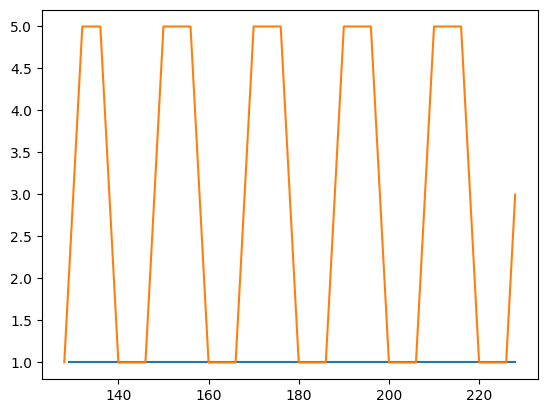

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.066355
256 train done
256 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.173618695568637


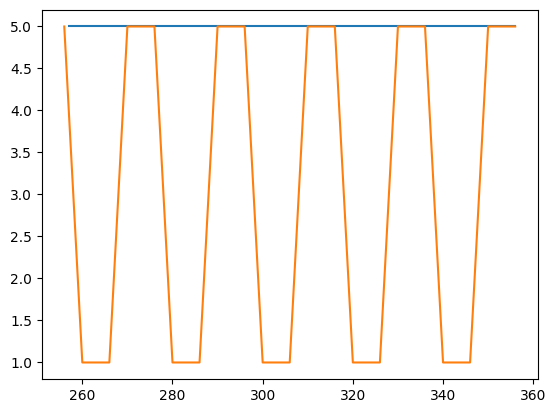

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.107784
512 train done
512 [4.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1868069244166162


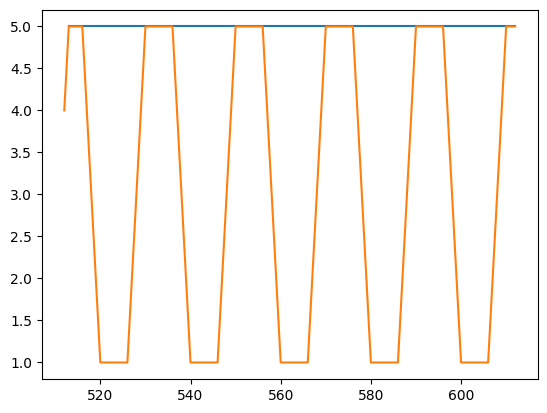

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.152292
750 train done
750 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
0.6297171984759831


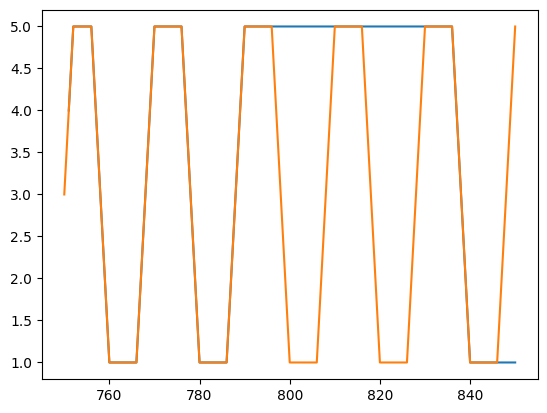

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.207066
1024 train done
1024 [2.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


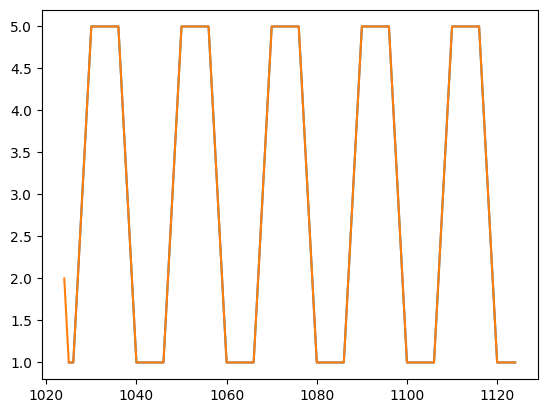

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.225464
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


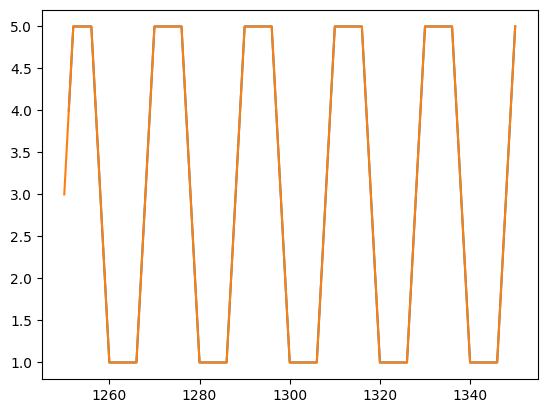

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.268708
1500 train done
1500 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.023149799999999915


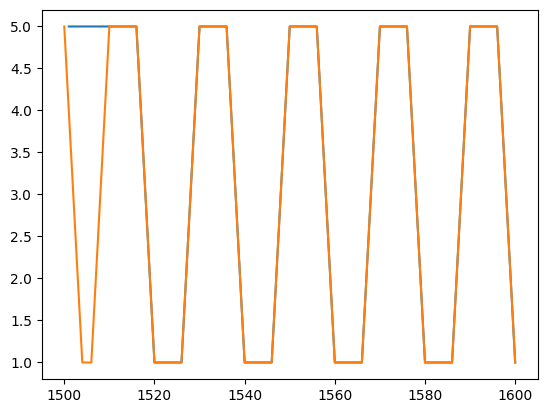

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.346560
2048 train done
2048 [3.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


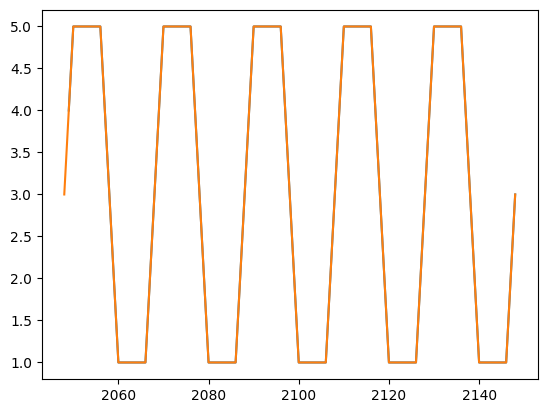

In [19]:
gamma = 0.5
Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
for t_prime in [6]:
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="pe")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]
        print(X_train.shape)
        #convert to proper format for ydf
        df_train = pd.DataFrame(X_train)
        feature_labels = [f'feature_{i}' for i in range(X_train.shape[1])]
        df_train.columns = feature_labels
        df_train['target'] = Y_train


        rf = RandomForestLearner(label = 'target', task = ydf.Task.REGRESSION, num_trees=1000)
        # rf = ObliqueRandomForestRegressor(n_estimators=1000)
        model = rf.train(df_train) #train now not fit
        print(T,'train done')
        current_state = states[T,0]
        # print(current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="pe")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                #convert to proper format for ydf
                features_pd = pd.DataFrame(features, columns = feature_labels)
                irewards_pred[:,i] = model.predict(features_pd)

            # # Compute instantaneous rewards
            # for i, row in df_all_paths.iterrows():
            #     for t in np.arange(t_prime+1):
            #         cand = row[f"t={T+delta_t+t}"]
            #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
            #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
            #         irewards_pred[i, t] = rf.predict(features)[0]

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()


    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/YDFRF_pe_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
        future_states =FUTURE_STATE_arr
        )

(128, 57)
Train model on 128 examples
Model trained in 0:00:00.026257
128 train done
128 [1.0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
1.0205543079618544


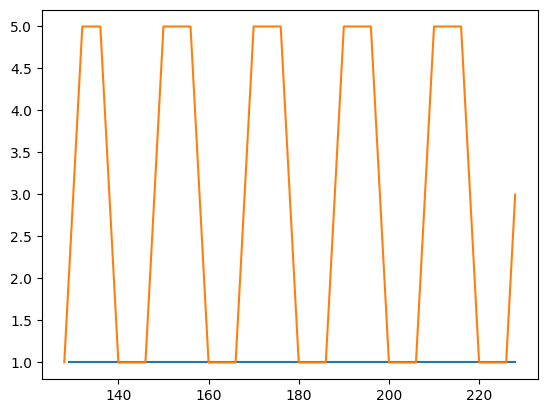

(256, 57)
Train model on 256 examples
Model trained in 0:00:00.094499
256 train done
256 [5.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.173618695568637


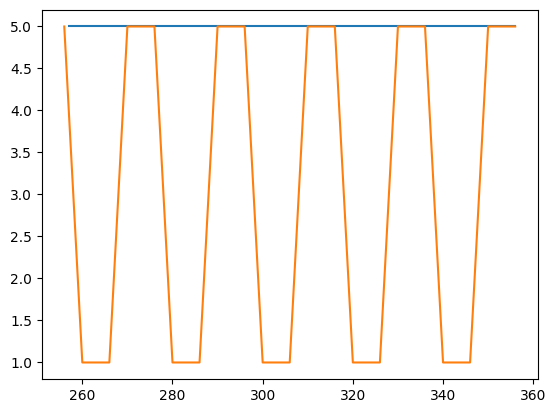

(512, 57)
Train model on 512 examples
Model trained in 0:00:00.120797
512 train done
512 [4.0, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5] 101
1.1868069244166162


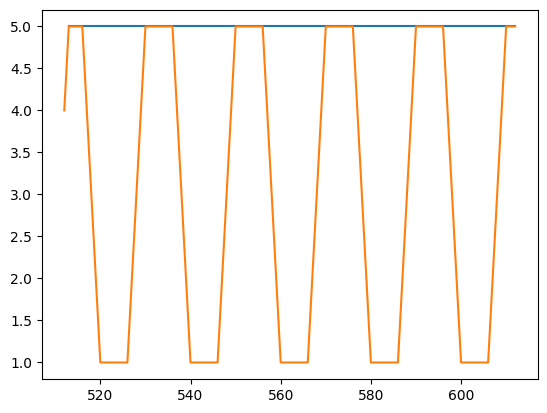

(750, 57)
Train model on 750 examples
Model trained in 0:00:00.163784
750 train done
750 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] 101
0.6297176082606839


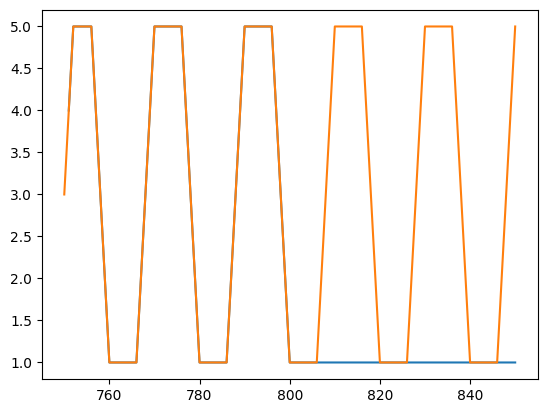

(1024, 57)
Train model on 1024 examples
Model trained in 0:00:00.221968
1024 train done
1024 [2.0, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1] 101
0.0


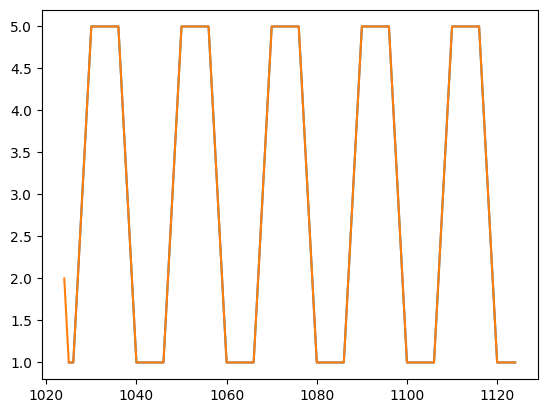

(1250, 57)
Train model on 1250 examples
Model trained in 0:00:00.251308
1250 train done
1250 [3.0, 4, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5] 101
0.0


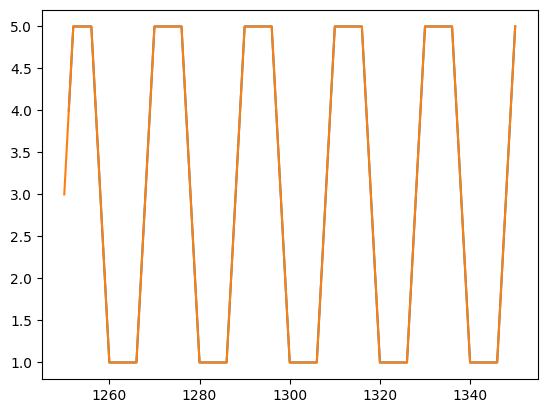

(1500, 57)
Train model on 1500 examples
Model trained in 0:00:00.523314
1500 train done
1500 [5.0, 6, 5, 4, 3, 2, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1] 101
0.01863000000000028


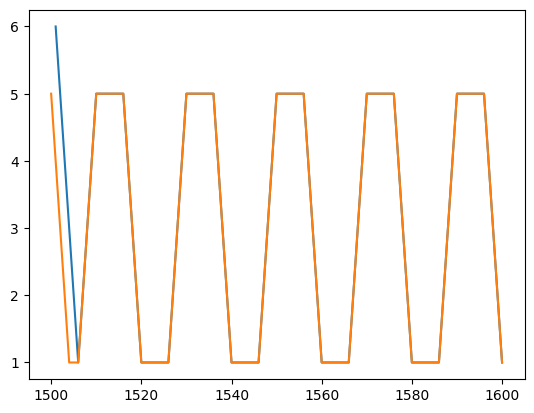

(2048, 57)
Train model on 2048 examples
Model trained in 0:00:00.400856
2048 train done
2048 [3.0, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1, 1, 1, 2, 3] 101
0.0


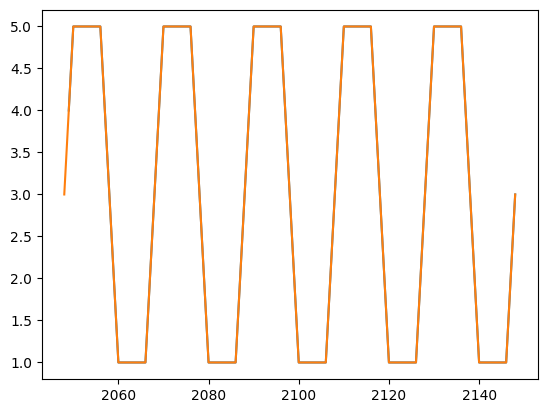

In [20]:
# gamma = 0.5
# Ts = [2**i for i in np.arange(7,10)]+[750]+[2**i for i in np.arange(10,12)]
# Ts = [2**i for i in np.arange(7,10)]+[750]+[1024,1250,1500,2048]
# Ts = [1024]
## Onehot Encoding
for t_prime in [6]:
    FUTURE_STATE = []
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                    session_duration = 500000,
                                                    tdim=50, 
                                                    n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])
    for T in Ts:
        X_train = new_state_oh[:T,:]
        Y_train = irewards[:T]
        print(X_train.shape)
        #convert to proper format for ydf
        df_train = pd.DataFrame(X_train)
        feature_labels = [f'feature_{i}' for i in range(X_train.shape[1])]
        df_train.columns = feature_labels
        df_train['target'] = Y_train


        rf = RandomForestLearner(label = 'target', task = ydf.Task.REGRESSION, num_trees=1000)
        # rf = ObliqueRandomForestRegressor(n_estimators=1000)
        model = rf.train(df_train) #train now not fit
        print(T,'train done')
        current_state = states[T,0]
        # print(current_state)
        future_states = [current_state]
        for delta_t in range(100):
            df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
            # print(f"Total paths: {len(df_all_paths)}")
            # states_seq = df_all_paths[state_cols].to_numpy() 

            n_paths = df_all_paths.shape[0]
            irewards_pred = np.zeros((n_paths,  t_prime+1))

            for i in range(t_prime+1):
                cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
                curr_time = T+1+delta_t+i
                time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
                features = np.hstack([cand_pe,time_emb])
                #convert to proper format for ydf
                features_pd = pd.DataFrame(features, columns = feature_labels)
                irewards_pred[:,i] = model.predict(features_pd)

            # # Compute instantaneous rewards
            # for i, row in df_all_paths.iterrows():
            #     for t in np.arange(t_prime+1):
            #         cand = row[f"t={T+delta_t+t}"]
            #         cand_onehot = ohe.transform(np.array(cand).reshape(1, -1)).toarray()
            #         features = np.hstack([cand_onehot.reshape(1,-1),time_embedding_np(T+delta_t+t, tdim=50).reshape(1, -1)])
            #         irewards_pred[i, t] = rf.predict(features)[0]

            # # Convert to DataFrame for inspection
            reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
            df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
            # Extract rewards from second column onward (t=1 to t=T)
            rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
            discounts = gamma ** np.arange(1, t_prime+1)

            # Compute discounted total reward per path
            discounted_returns = rewards_matrix * discounts  
            total_discounted = discounted_returns.sum(axis=1)
            # print(total_discounted)
            bext_idx = np.argmax(total_discounted)
            next_state = int(df_all_paths.iloc[bext_idx,1])
            # print(df_all_paths.iloc[bext_idx,:])
            future_states.append(next_state)
            current_state = next_state
            # print(T+delta_t+1,current_state)
        print(T,future_states,len(future_states))
        FUTURE_STATE.append(future_states)

        irewards_test = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
        preward = compute_normalized_future_rewards(irewards_test,100,0.5)
        path, ireward_opt = path_opt(future_states[0], T, 100)
        preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
        print(pregret)
        plt.plot(np.arange(T+1,T+101),future_states[1:])
        plt.plot(np.arange(T,T+101),path)
        plt.show()


    FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
    np.savez(
        f"../results/PAFM/YDFRF_oh_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
        future_states =FUTURE_STATE_arr
        )


## PAFM optimal (nothing changed from PAFM_RF_BF)

25
(150, 57) (150,)
128 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


1.1155543079618544


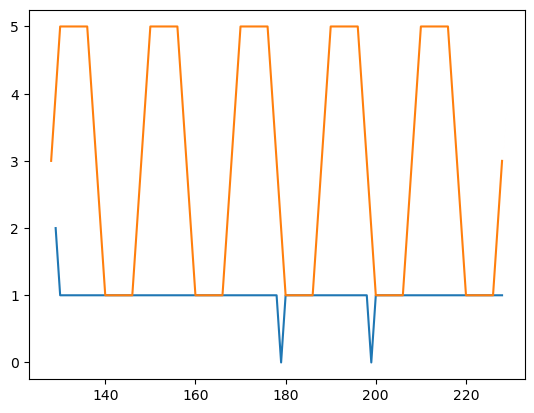

51
(306, 57) (306,)
256 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


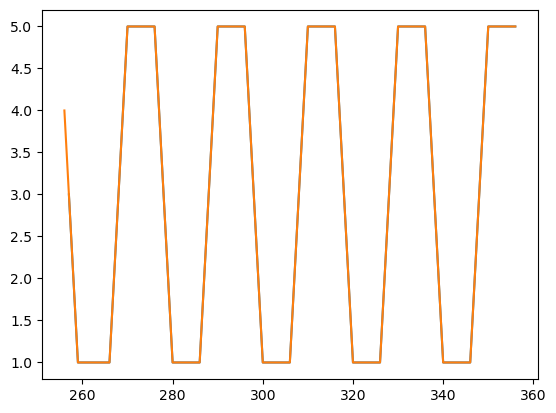

102
(612, 57) (612,)
512 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.009914400000000115


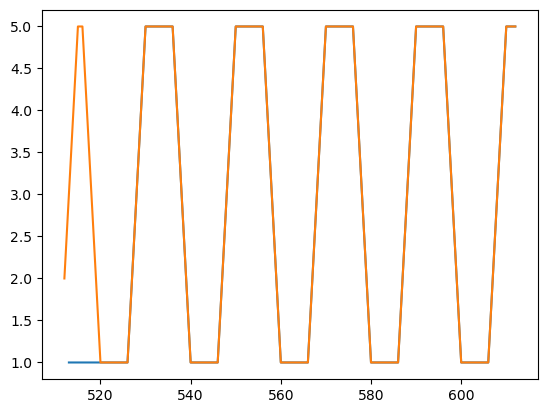

150
(900, 57) (900,)
750 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


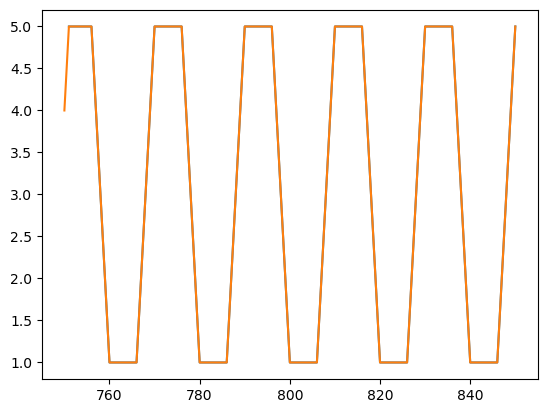

204
(1224, 57) (1224,)
1024 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


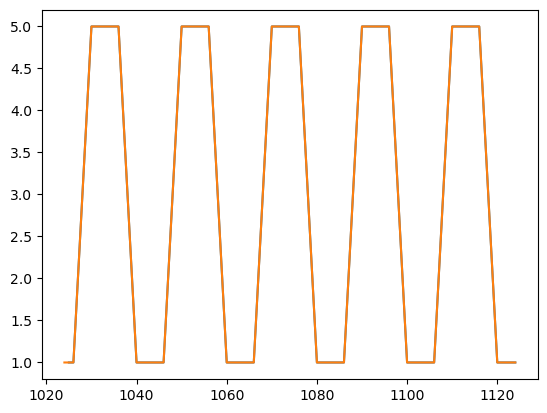

250
(1500, 57) (1500,)
1250 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0231498000000002


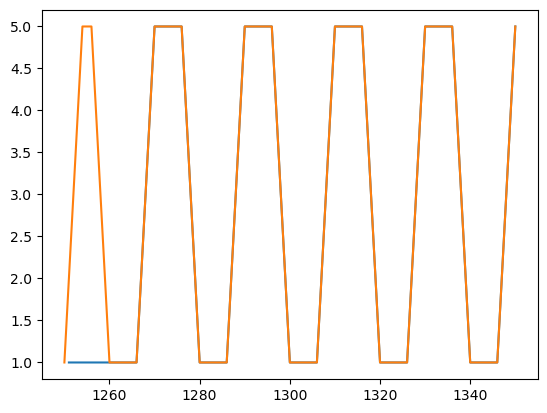

300
(1800, 57) (1800,)
1500 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.03934979999999996


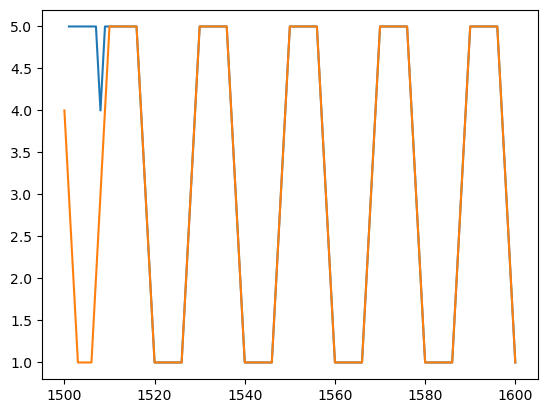

409
(2454, 57) (2454,)
2048 train done


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_62644/1215209319.py:63: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_state = int(df_all_paths.iloc[bext_idx,1])


0.0


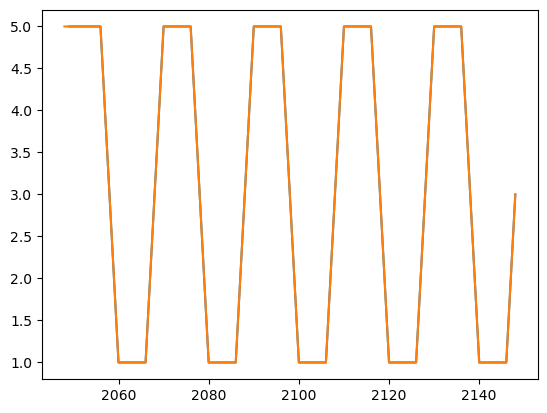

In [9]:
DELTA_t = 5
t_prime = 6
FUTURE_STATE = []
for T in Ts:
    n_seq = int(T/DELTA_t)
    # n_seq = T
    print(n_seq)
    state_raw = np.random.choice([int(i) for i in range(7)],size = n_seq)
    time_raw = np.random.choice([int(i) for i in range(T)],size = n_seq)
    opt_paths, opt_times, opt_irewards, opt_prewards = [], [], [], []
    STATES = []
    for i in range(len(time_raw)):
        path, rewards = path_opt(state_raw[i], time_raw[i], DELTA_t)
        # print(state_raw[i],path)
        times = [time_raw[i]+delta_t for delta_t in np.arange(1,DELTA_t+2)] # raw time begin from 1
        opt_paths.append(path)
        opt_irewards.append(rewards)
        opt_times.append(times)
        opt_prewards.append(preward_opt(rewards,gamma = 0.5))
        state_posencode_oh = position_encoder(np.array(path), type="onehot")
        time_emb = time_embedding_np(np.array(times)).reshape(DELTA_t+1,-1)
        # print(time_emb.shape,state_posencode_oh.shape)
        state_pe = np.hstack([state_posencode_oh,time_emb])
        STATES.append(state_pe)
    STATES_arr = np.vstack(STATES)
    REWARDS_arr = np.hstack(np.array(opt_irewards).reshape(-1,1))
    print(STATES_arr.shape,REWARDS_arr.shape)
    # plt.plot(opt_times[0],opt_paths[0])
    # plt.show()
    # plt.plot(opt_times[0],opt_irewards[0])
    # plt.show()
    X_train = STATES_arr
    Y_train = REWARDS_arr
    rf = RandomForestRegressor(n_estimators=1000, random_state=9515)
    rf.fit(X_train, Y_train)
    print(T,'train done')

    
    current_state = np.random.choice([int(i) for i in range(7)],size = 1)
    future_states = [current_state.item()]
    # print(current_state)
    for delta_t in range(100):
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        n_paths = df_all_paths.shape[0]
        irewards_pred = np.zeros((n_paths,  t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            irewards_pred[:,i] = rf.predict(features)
        reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
        df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
        # Extract rewards from second column onward (t=1 to t=T)
        rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
        discounts = gamma ** np.arange(1, t_prime+1)

        # Compute discounted total reward per path
        discounted_returns = rewards_matrix * discounts  
        total_discounted = discounted_returns.sum(axis=1)
        # print(total_discounted)
        bext_idx = np.argmax(total_discounted)
        next_state = int(df_all_paths.iloc[bext_idx,1])
        # print(df_all_paths.iloc[bext_idx,:])
        future_states.append(next_state)
        current_state = next_state
    
    # print(T,future_states,len(future_states))
    FUTURE_STATE.append(future_states)

    irewards = [reward_simulate(future_states[i],T+i,rewards_in_period) for i in np.arange(1,len(future_states))]
    preward = compute_normalized_future_rewards(irewards,100,0.5)
    path, ireward_opt = path_opt(future_states[0], T, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
    pregret = (np.sum(preward_opt_test).item()-np.sum(preward).item())/100
    print(pregret)
    plt.plot(np.arange(T+1,T+101),future_states[1:])
    plt.plot(np.arange(T,T+101),path)
    plt.show()

FUTURE_STATE_arr = np.vstack(FUTURE_STATE)
np.savez(
    f"../results/PAFM/RF_optimal_oh_w_time128_2048_lookahead{t_prime}_reps{0}.npz",
    future_states =FUTURE_STATE_arr
    )

